In [1]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.cluster.hierarchy import linkage, fcluster

# Start from ESMDynamic prediction

In [2]:
esmd_map = np.load("OsSWEET2b_esmdynamic_contact_map.npy")

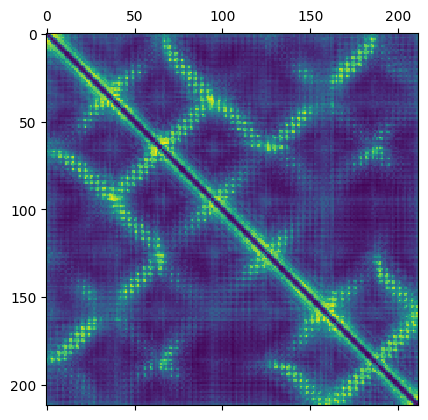

In [3]:
plt.matshow(esmd_map)
plt.show()

# Filtering step

Avoid residues within 40 positions of each other. This helps eliminate local contacts.

In [4]:
rows, cols = esmd_map.shape
points_of_interest = np.asarray([(i, j) for i in range(rows) for j in range(i+40, cols) if esmd_map[i, j] > 0.5])

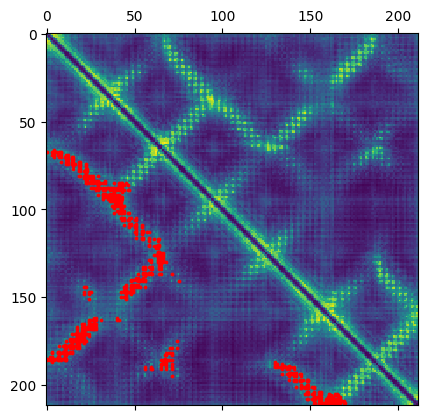

In [5]:
plt.matshow(esmd_map)
plt.scatter(points_of_interest[:, 0], points_of_interest[:, 1], c='r', s=3)
plt.show()

# Clustering step

Linkage based clustering.

In [6]:
linkage_matrix = linkage(points_of_interest, method="single", metric="cityblock")

In [7]:
# Form clusters (e.g., cut the tree into `n_clusters` clusters)
n_clusters = 9  # I'm comparing against a previous paper (Selvam, Balaji, et al. ACS central science 5.6 (2019): 1085-1096.)
labels = fcluster(linkage_matrix, n_clusters, criterion="maxclust")

# Group points based on cluster labels
clusters = {i: [] for i in range(1, n_clusters + 1)}
for point, label in zip(points_of_interest, labels):
    clusters[label].append(tuple(point))

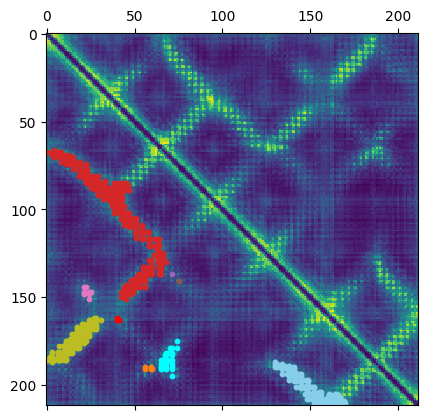

In [8]:
grid = esmd_map.copy()
plt.matshow(grid)
colors = [  # Try to make them distinguishable
    "#87CEEB",  
    "#ff7f0e",  
    "#00FFFF",  
    "#d62728",  
    "#9467bd",  
    "#8c564b",  
    "#e377c2",  
    "#FF0000",
    "#bcbd22"   
]

for i, (cluster_id, points) in enumerate(clusters.items()):
    points = np.array(points)
    plt.scatter(points[:, 0], points[:, 1], label=f"Cluster {cluster_id}", s=10, c=colors[i])
plt.show()

# Select CVs

Pick highest prob. from each cluster.

In [10]:
chosen_coordinates = []
for i, (cluster_id, points) in enumerate(clusters.items()):
    scores = []
    points = np.array(points)
    for p in points:
        scores.append(esmd_map[p[0], p[1]])
    scores = np.asarray(scores)
    chosen_coordinates.append(points[np.argmax(scores)])
chosen_coordinates = np.asarray(chosen_coordinates)

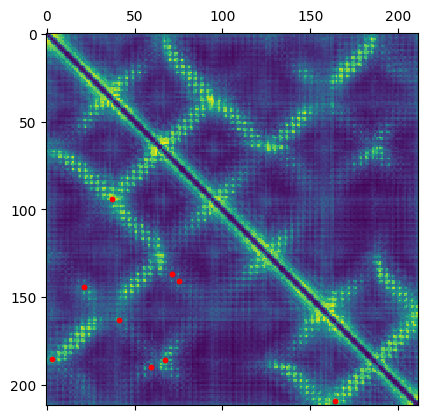

In [12]:
plt.matshow(esmd_map)
plt.scatter(chosen_coordinates[:, 0], chosen_coordinates[:, 1], c='r', s=10)
plt.show()